In [3]:
# Name: Jeevan Vishal.G.D
# Reg No: 212224240062
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


import numpy as np
import pandas as pd 
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
transform = transforms.ToTensor()



In [5]:
train_data = datasets.MNIST(root='../Data', train=True, download=True, transform=transform)

In [6]:
test_data = datasets.MNIST(root='../Data', train=False, download=True, transform=transform)

In [7]:
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [8]:
class ConvolutionalNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        self.fc1 = nn.Linear(5*5*16,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, 5*5*16)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X, dim=1)

In [9]:
torch.manual_seed(42)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
import time
start_time = time.time()

# Variables ( Trackers)
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# for loop epochs 
for i in range(epochs):
    
    trn_corr = 0
    tst_corr = 0


    # Run the training batches
    for b, (X_train, y_train) in enumerate(train_loader):
        b+=1
        
        # Apply the model
        y_pred = model(X_train)  # we not flatten X-train here
        loss = criterion(y_pred, y_train)
 
        
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()  # Trure 1 / False 0 sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print interim results
        if b%600 == 0:
            print(f'epoch: {i}  batch: {b} loss: {loss.item()}')
        
    train_losses.append(loss)
    train_correct.append(trn_corr)
        
    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):

            # Apply the model
            y_val = model(X_test)

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()
            
    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)
        
current_time = time.time()
total = current_time - start_time
print(f'Training took {total/60} minutes')

epoch: 0  batch: 600 loss: 0.04255058988928795
epoch: 0  batch: 1200 loss: 0.08127405494451523
epoch: 0  batch: 1800 loss: 0.31574493646621704
epoch: 0  batch: 2400 loss: 0.02466626651585102
epoch: 0  batch: 3000 loss: 0.006747593637555838
epoch: 0  batch: 3600 loss: 0.0011479314416646957
epoch: 0  batch: 4200 loss: 0.44552022218704224
epoch: 0  batch: 4800 loss: 0.03962809965014458
epoch: 0  batch: 5400 loss: 0.010058023035526276
epoch: 0  batch: 6000 loss: 0.050790805369615555
epoch: 1  batch: 600 loss: 0.02081066370010376
epoch: 1  batch: 1200 loss: 0.04013160988688469
epoch: 1  batch: 1800 loss: 0.0016949968412518501
epoch: 1  batch: 2400 loss: 0.02197723649442196
epoch: 1  batch: 3000 loss: 0.46340975165367126
epoch: 1  batch: 3600 loss: 0.0031111743301153183
epoch: 1  batch: 4200 loss: 0.0006842638249509037
epoch: 1  batch: 4800 loss: 0.0009595296578481793
epoch: 1  batch: 5400 loss: 0.005347493104636669
epoch: 1  batch: 6000 loss: 0.0238035935908556
epoch: 2  batch: 600 loss: 0.

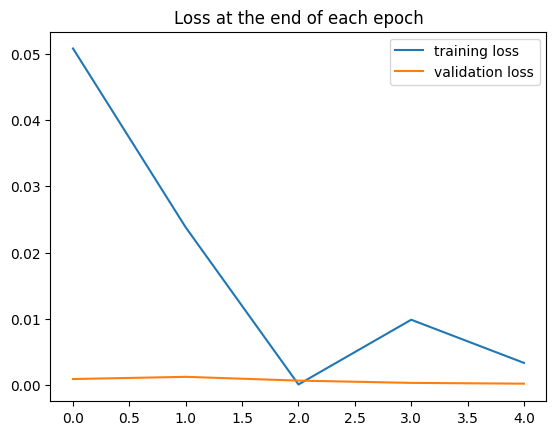

In [12]:
# Detach and convert to NumPy
train_losses = [t.detach().numpy() for t in train_losses]
test_losses = [t.detach().numpy() for t in test_losses]

plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend();
plt.show()


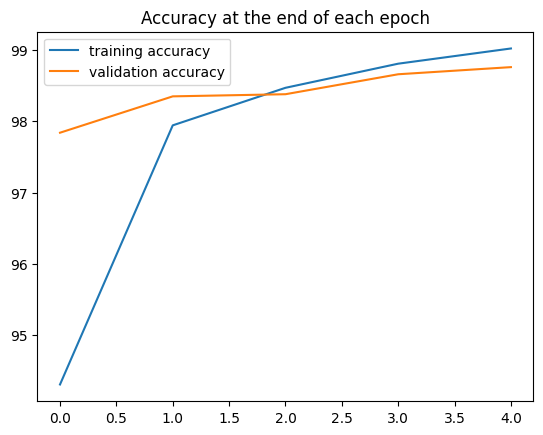

In [13]:
plt.plot([t/600 for t in train_correct], label='training accuracy')
plt.plot([t/100 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();
plt.show()

In [14]:
# Extract the data all at once, not in batches
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

In [15]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        y_val = model(X_test)  # we don't flatten the data this time
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()

In [18]:
# print a row of values for reference
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}'))
print(np.arange(10).reshape(1,10))
print()

# print the confusion matrix
print(confusion_matrix(predicted.view(-1), y_test.view(-1)))

[[   0    1    2    3    4    5    6    7    8    9]]

[[ 976    0    1    0    0    2    4    1    4    0]
 [   0 1128    1    0    0    0    3    3    0    2]
 [   2    2 1027    2    1    0    2    7    3    0]
 [   0    3    0 1003    0   10    0    2    4    1]
 [   0    0    1    0  978    0    2    2    1   10]
 [   0    0    0    2    0  872    5    0    1    2]
 [   1    1    0    0    1    2  940    0    0    0]
 [   1    0    1    2    0    1    0 1009    0    6]
 [   0    1    1    1    1    1    2    2  959    4]
 [   0    0    0    0    1    4    0    2    2  984]]


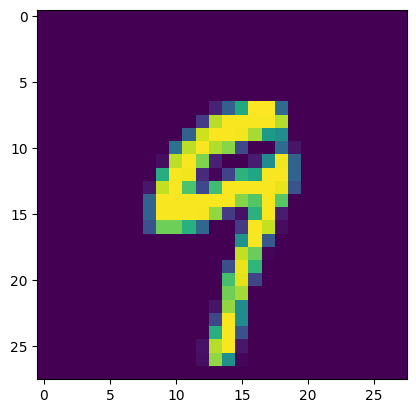

In [19]:
# single image for test 
plt.imshow(test_data[2019][0].reshape(28,28))
plt.show()

In [20]:
model.eval()
with torch.no_grad():
    new_prediction = model(test_data[2019][0].view(1,1,28,28))

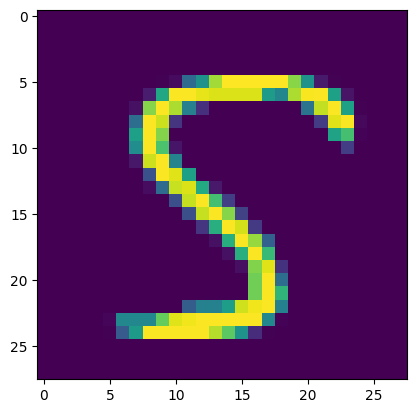

In [22]:
# single image for test 
plt.imshow(test_data[333][0].reshape(28,28))
plt.show()

In [23]:
model.eval()
with torch.no_grad():
    new_prediction = model(test_data[333][0].view(1,1,28,28))

In [24]:
test_data[333][1]

5